In [12]:
import os
import numpy as np

# Correct paths
BASE_DIR = "/kaggle/input/datasets/abishah/semicon"

GT_DIR = os.path.join(BASE_DIR, "train", "train", "GT")
NOISY_DIR = os.path.join(BASE_DIR, "train", "train", "NoisyLR")
TEST_DIR = os.path.join(BASE_DIR, "Test_NoisyLR", "NoisyLR")

# Get filenames
gt_files = sorted([f for f in os.listdir(GT_DIR) if f.endswith(".npy")])
noisy_files = sorted([f for f in os.listdir(NOISY_DIR) if f.endswith(".npy")])
test_files = sorted([f for f in os.listdir(TEST_DIR) if f.endswith(".npy")])

print("Number of GT images      :", len(gt_files))
print("Number of NoisyLR images :", len(noisy_files))
print("Number of Test images    :", len(test_files))

print("\nFirst GT file     :", gt_files[0])
print("First NoisyLR file:", noisy_files[0])

# Load the first matching pair
gt = np.load(os.path.join(GT_DIR, gt_files[0]))
noisy = np.load(os.path.join(NOISY_DIR, gt_files[0]))

print("\n========== GROUND TRUTH ==========")
print("Shape :", gt.shape)
print("Dtype :", gt.dtype)
print("Min   :", gt.min())
print("Max   :", gt.max())
print("Mean  :", gt.mean())
print("Std   :", gt.std())

print("\n========== NOISY LR ==========")
print("Shape :", noisy.shape)
print("Dtype :", noisy.dtype)
print("Min   :", noisy.min())
print("Max   :", noisy.max())
print("Mean  :", noisy.mean())
print("Std   :", noisy.std())

print("\n========== PAIR CHECK ==========")
print("Same filename :", gt_files[0] == noisy_files[0])

Number of GT images      : 3200
Number of NoisyLR images : 3200
Number of Test images    : 400

First GT file     : 000000.npy
First NoisyLR file: 000000.npy

========== GROUND TRUTH ==========
Shape : (256, 256)
Dtype : float32
Min   : 0.0
Max   : 1.0
Mean  : 0.21819249
Std   : 0.23950556

========== NOISY LR ==========
Shape : (128, 128)
Dtype : float32
Min   : -0.0026427102
Max   : 1.3257757
Mean  : 0.21844144
Std   : 0.2448654

========== PAIR CHECK ==========
Same filename : True


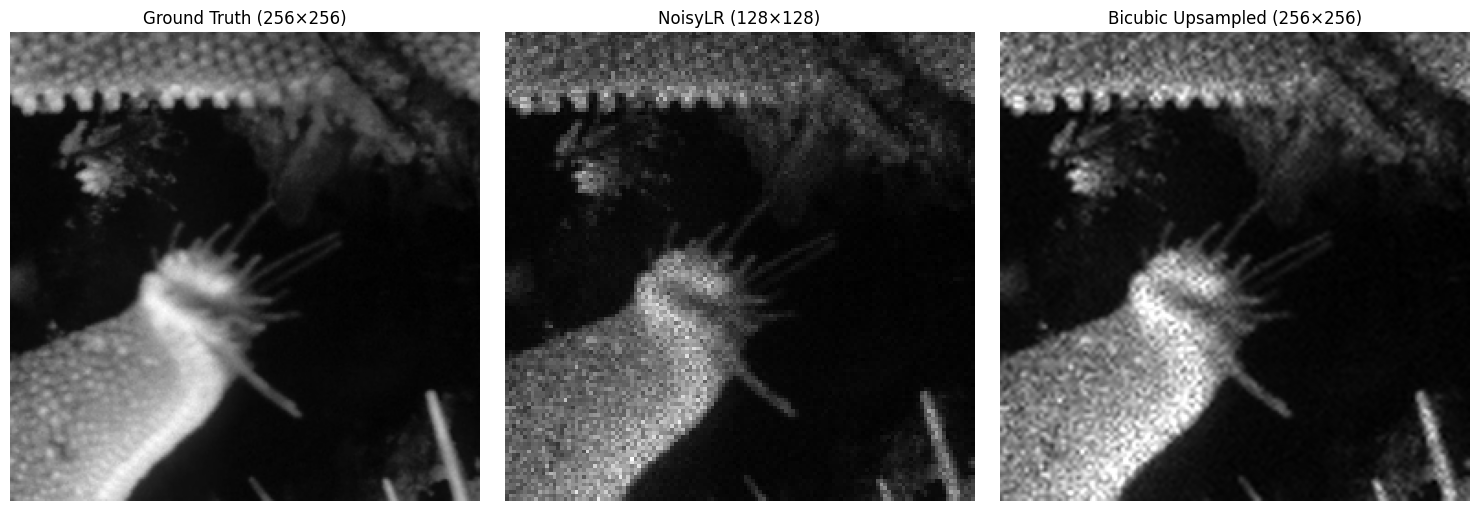

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Load one training pair
sample_id = "000000"

gt = np.load(os.path.join(GT_DIR, sample_id + ".npy"))
noisy = np.load(os.path.join(NOISY_DIR, sample_id + ".npy"))

# Bicubic upsampling for visual comparison
from scipy.ndimage import zoom

noisy_up = zoom(noisy, 2, order=3)

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gt, cmap="gray", vmin=0, vmax=1)
plt.title("Ground Truth (256×256)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(noisy, cmap="gray")
plt.title("NoisyLR (128×128)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(noisy_up, cmap="gray", vmin=0, vmax=1)
plt.title("Bicubic Upsampled (256×256)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import os
from scipy.ndimage import zoom
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

psnr_scores = []
ssim_scores = []

print("Calculating Bicubic baseline...")
print("This may take a little while.\n")

for i, filename in enumerate(gt_files):

    # Load ground truth and degraded image
    gt = np.load(os.path.join(GT_DIR, filename))
    noisy = np.load(os.path.join(NOISY_DIR, filename))

    # Bicubic upsampling: 128x128 -> 256x256
    bicubic = zoom(noisy, 2, order=3)

    # Final image must be in the valid GT range
    bicubic = np.clip(bicubic, 0.0, 1.0)

    # Calculate PSNR
    psnr = peak_signal_noise_ratio(
        gt,
        bicubic,
        data_range=1.0
    )

    # Calculate SSIM
    ssim = structural_similarity(
        gt,
        bicubic,
        data_range=1.0
    )

    psnr_scores.append(psnr)
    ssim_scores.append(ssim)

    if (i + 1) % 500 == 0:
        print(f"Processed {i + 1}/{len(gt_files)} images")

# Final results
mean_psnr = np.mean(psnr_scores)
mean_ssim = np.mean(ssim_scores)

print("\n==============================")
print("BICUBIC BASELINE RESULTS")
print("==============================")
print(f"Images evaluated : {len(gt_files)}")
print(f"Mean PSNR        : {mean_psnr:.4f} dB")
print(f"Mean SSIM        : {mean_ssim:.6f}")
print("==============================")

Calculating Bicubic baseline...
This may take a little while.

Processed 500/3200 images
Processed 1000/3200 images
Processed 1500/3200 images
Processed 2000/3200 images
Processed 2500/3200 images
Processed 3000/3200 images

BICUBIC BASELINE RESULTS
Images evaluated : 3200
Mean PSNR        : 22.9491 dB
Mean SSIM        : 0.539191


In [4]:
from sklearn.model_selection import train_test_split

# All filenames
all_files = sorted(gt_files)

# 90% training, 10% validation
train_files, val_files = train_test_split(
    all_files,
    test_size=0.10,
    random_state=42
)

print("Dataset split completed")
print("-------------------------")
print("Total images     :", len(all_files))
print("Training images  :", len(train_files))
print("Validation images:", len(val_files))

print("\nFirst 5 training files:")
print(train_files[:5])

print("\nFirst 5 validation files:")
print(val_files[:5])

Dataset split completed
-------------------------
Total images     : 3200
Training images  : 2880
Validation images: 320

First 5 training files:
['002229.npy', '002820.npy', '001957.npy', '003046.npy', '002653.npy']

First 5 validation files:
['002384.npy', '002538.npy', '002176.npy', '000897.npy', '000214.npy']


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

class SemiconDataset(Dataset):

    def __init__(self, filenames, noisy_dir, gt_dir):
        self.filenames = filenames
        self.noisy_dir = noisy_dir
        self.gt_dir = gt_dir

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):

        filename = self.filenames[idx]

        # Load .npy files
        noisy = np.load(
            os.path.join(self.noisy_dir, filename)
        ).astype(np.float32)

        gt = np.load(
            os.path.join(self.gt_dir, filename)
        ).astype(np.float32)

        # Convert to tensors
        noisy = torch.from_numpy(noisy)
        gt = torch.from_numpy(gt)

        # Add channel dimension
        # 128x128 -> 1x128x128
        noisy = noisy.unsqueeze(0)

        # 256x256 -> 1x256x256
        gt = gt.unsqueeze(0)

        # Upsample noisy image to 256x256
        noisy = F.interpolate(
            noisy.unsqueeze(0),
            size=(256, 256),
            mode="bicubic",
            align_corners=False
        ).squeeze(0)

        return noisy, gt


# Create datasets
train_dataset = SemiconDataset(
    train_files,
    NOISY_DIR,
    GT_DIR
)

val_dataset = SemiconDataset(
    val_files,
    NOISY_DIR,
    GT_DIR
)


print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))


# Check one sample
sample_input, sample_gt = train_dataset[0]

print("\nSample input shape :", sample_input.shape)
print("Sample GT shape    :", sample_gt.shape)

print("\nInput min :", sample_input.min().item())
print("Input max :", sample_input.max().item())

print("\nGT min :", sample_gt.min().item())
print("GT max :", sample_gt.max().item())

Training dataset: 2880
Validation dataset: 320

Sample input shape : torch.Size([1, 256, 256])
Sample GT shape    : torch.Size([1, 256, 256])

Input min : -0.05272737145423889
Input max : 1.5590388774871826

GT min : 0.0
GT max : 1.0


In [6]:
import torch
from torch.utils.data import DataLoader

In [8]:
# ============================================
# STEP 6 — CREATE DATALOADERS
# ============================================

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("DataLoaders created successfully")
print("--------------------------------")
print("Training batches  :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Batch size        :", BATCH_SIZE)


# Check one training batch
batch_input, batch_gt = next(iter(train_loader))

print("\nBatch input shape :", batch_input.shape)
print("Batch GT shape    :", batch_gt.shape)
print("Input dtype       :", batch_input.dtype)
print("GT dtype          :", batch_gt.dtype)


# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\nDevice:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DataLoaders created successfully
--------------------------------
Training batches  : 180
Validation batches: 20
Batch size        : 16

Batch input shape : torch.Size([16, 1, 256, 256])
Batch GT shape    : torch.Size([16, 1, 256, 256])
Input dtype       : torch.float32
GT dtype          : torch.float32

Device: cuda
GPU: Tesla T4


In [9]:
import torch
import torch.nn as nn

# ==========================================
# Residual U-Net for Image Restoration
# ==========================================

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self, x):
        return x + self.block(x)


class UNetRestoration(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            ResidualBlock(64)
        )

        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            ResidualBlock(128)
        )

        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            ResidualBlock(256)
        )

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.ReLU(inplace=True),
            ResidualBlock(512),
            ResidualBlock(512)
        )

        # Decoder
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)

        self.dec3 = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            ResidualBlock(256)
        )

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)

        self.dec2 = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            ResidualBlock(128)
        )

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)

        self.dec1 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            ResidualBlock(64)
        )

        # Output
        self.output = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)

        e2 = self.enc2(self.pool(e1))

        e3 = self.enc3(self.pool(e2))

        # Bottleneck
        b = self.bottleneck(self.pool(e3))

        # Decoder
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        # Residual restoration
        out = self.output(d1)

        return out


# Create model
model = UNetRestoration().to(device)

print("Model created successfully!")
print("Device:", device)

# Number of parameters
total_params = sum(p.numel() for p in model.parameters())

print("Total parameters:", f"{total_params:,}")

Model created successfully!
Device: cuda
Total parameters: 16,325,313


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
import math

# ============================================================
# TRAINING SETUP
# ============================================================

criterion = nn.L1Loss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-6
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

num_epochs = 20

best_val_loss = float('inf')

train_losses = []
val_losses = []

print("Training setup completed!")
print("Epochs:", num_epochs)
print("Learning rate:", 1e-4)

Training setup completed!
Epochs: 20
Learning rate: 0.0001


In [13]:
import time

# ============================================================
# TRAINING LOOP WITH EPOCH TIMING
# ============================================================

epoch_times = []

for epoch in range(num_epochs):

    epoch_start = time.time()

    # -------------------------
    # TRAINING
    # -------------------------
    model.train()

    running_train_loss = 0.0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{num_epochs} [Train]"
    )

    for noisy, gt in train_bar:

        noisy = noisy.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        noisy = torch.clamp(noisy, 0.0, 1.0)

        optimizer.zero_grad()

        output = model(noisy)
        output = torch.clamp(output, 0.0, 1.0)

        loss = criterion(output, gt)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        train_bar.set_postfix(
            loss=f"{loss.item():.5f}"
        )

    avg_train_loss = running_train_loss / len(train_loader)


    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        val_bar = tqdm(
            val_loader,
            desc=f"Epoch {epoch+1}/{num_epochs} [Val]"
        )

        for noisy, gt in val_bar:

            noisy = noisy.to(device, non_blocking=True)
            gt = gt.to(device, non_blocking=True)

            noisy = torch.clamp(noisy, 0.0, 1.0)

            output = model(noisy)
            output = torch.clamp(output, 0.0, 1.0)

            loss = criterion(output, gt)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)

    scheduler.step(avg_val_loss)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)


    # -------------------------
    # EPOCH TIME
    # -------------------------
    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)

    avg_epoch_time = sum(epoch_times) / len(epoch_times)

    remaining_epochs = num_epochs - (epoch + 1)
    estimated_remaining = remaining_epochs * avg_epoch_time


    # -------------------------
    # SAVE BEST MODEL
    # -------------------------
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(
            model.state_dict(),
            "/kaggle/working/best_model.pth"
        )

        saved = " <-- BEST MODEL SAVED"

    else:
        saved = ""


    print("\n" + "=" * 60)
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss       : {avg_train_loss:.6f}")
    print(f"Validation Loss  : {avg_val_loss:.6f}")
    print(f"Epoch Time       : {epoch_time/60:.2f} minutes")
    print(f"Average Epoch    : {avg_epoch_time/60:.2f} minutes")
    print(f"Estimated Remaining: {estimated_remaining/60:.2f} minutes")
    print(f"Best Val Loss    : {best_val_loss:.6f}{saved}")
    print("=" * 60)


print("\n==============================================")
print("TRAINING COMPLETED")
print("==============================================")

print(f"Best Validation Loss : {best_val_loss:.6f}")
print(f"Average Epoch Time   : {sum(epoch_times)/len(epoch_times)/60:.2f} minutes")
print(f"Total Training Time  : {sum(epoch_times)/60:.2f} minutes")


Epoch 1/20 [Train]:   0%|          | 0/180 [00:00<?, ?it/s]

Epoch 1/20 [Val]:   0%|          | 0/20 [00:00<?, ?it/s]


Epoch [1/20]
Train Loss       : 0.031134
Validation Loss  : 0.031172
Epoch Time       : 3.28 minutes
Average Epoch    : 3.28 minutes
Estimated Remaining: 62.23 minutes
Best Val Loss    : 0.031172 <-- BEST MODEL SAVED


Epoch 2/20 [Train]:   0%|          | 0/180 [00:00<?, ?it/s]

Epoch 2/20 [Val]:   0%|          | 0/20 [00:00<?, ?it/s]

...

Epoch 19/20 [Val]:   0%|          | 0/20 [00:00<?, ?it/s]


Epoch [19/20]
Train Loss       : 0.029913
Validation Loss  : 0.030407
Epoch Time       : 3.30 minutes
Average Epoch    : 3.31 minutes
Estimated Remaining: 3.31 minutes
Best Val Loss    : 0.030324


Epoch 20/20 [Train]:   0%|          | 0/180 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/20 [00:00<?, ?it/s]


Epoch [20/20]
Train Loss       : 0.030147
Validation Loss  : 0.031191
Epoch Time       : 3.26 minutes
Average Epoch    : 3.30 minutes
Estimated Remaining: 0.00 minutes
Best Val Loss    : 0.030324

TRAINING COMPLETED
Best Validation Loss : 0.030324
Average Epoch Time   : 3.30 minutes
Total Training Time  : 66.08 minutes


In [14]:
import os

print("Files saved in /kaggle/working:")

for f in os.listdir("/kaggle/working"):
    print(f)

Files saved in /kaggle/working:
best_model.pth
.virtual_documents


In [15]:
# Load the best U-Net model

MODEL_PATH = "/kaggle/working/best_model.pth"

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

model = model.to(device)
model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [16]:
TEST_DIR = "/kaggle/input/datasets/abishah/semicon/Test_NoisyLR/NoisyLR"

test_files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.endswith(".npy")
])

print("Number of test images:", len(test_files))
print("First 5 test files:", test_files[:5])

Number of test images: 400
First 5 test files: ['000000.npy', '000001.npy', '000002.npy', '000003.npy', '000004.npy']


In [17]:
TEST_ROOT = "/kaggle/input/datasets/abishah/semicon/Test_NoisyLR"

for root, dirs, files in os.walk(TEST_ROOT):
    print(root, "->", len(files), "files")

/kaggle/input/datasets/abishah/semicon/Test_NoisyLR -> 0 files
/kaggle/input/datasets/abishah/semicon/Test_NoisyLR/NoisyLR -> 400 files


In [18]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Select one test image
test_file = test_files[0]

# Load noisy LR image
noisy_lr = np.load(os.path.join(TEST_DIR, test_file)).astype(np.float32)

print("Test file:", test_file)
print("Original shape:", noisy_lr.shape)

Test file: 000000.npy
Original shape: (128, 128)


In [19]:
import torch.nn.functional as F

# Convert numpy → tensor
input_tensor = torch.from_numpy(noisy_lr).unsqueeze(0).unsqueeze(0)

# Move to GPU
input_tensor = input_tensor.to(device)

# Upscale 128×128 → 256×256
input_tensor = F.interpolate(
    input_tensor,
    size=(256, 256),
    mode="bicubic",
    align_corners=False
)

print("Model input shape:", input_tensor.shape)

Model input shape: torch.Size([1, 1, 256, 256])


In [20]:
with torch.no_grad():
    restored = model(input_tensor)

print("Restored shape:", restored.shape)

Restored shape: torch.Size([1, 1, 256, 256])


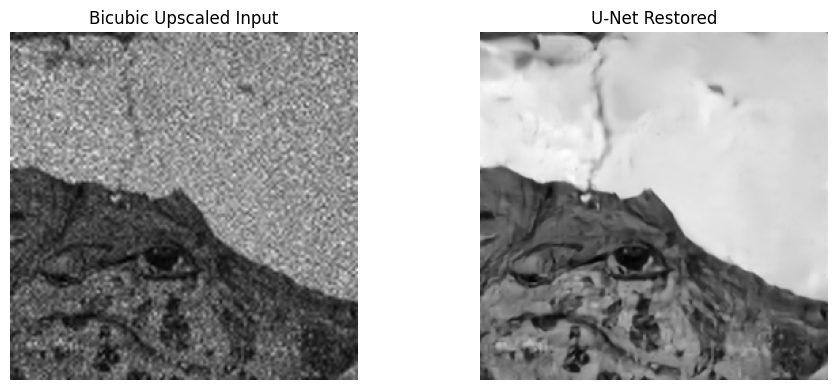

In [21]:
input_display = input_tensor[0, 0].cpu().numpy()
restored_display = restored[0, 0].cpu().numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(input_display, cmap="gray")
plt.title("Bicubic Upscaled Input")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(restored_display, cmap="gray")
plt.title("U-Net Restored")
plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
import time

# Warm-up
with torch.no_grad():
    _ = model(input_tensor)

if torch.cuda.is_available():
    torch.cuda.synchronize()

start_time = time.time()

with torch.no_grad():
    _ = model(input_tensor)

if torch.cuda.is_available():
    torch.cuda.synchronize()

end_time = time.time()

inference_time = end_time - start_time

print(f"Inference time: {inference_time*1000:.2f} ms/image")

Inference time: 37.85 ms/image


In [23]:
import time
import numpy as np
import torch.nn.functional as F

results = []

model.eval()

total_start = time.time()

for i, filename in enumerate(test_files):

    # Load image
    noisy_lr = np.load(
        os.path.join(TEST_DIR, filename)
    ).astype(np.float32)

    # Convert to tensor
    x = torch.from_numpy(noisy_lr).unsqueeze(0).unsqueeze(0)
    x = x.to(device)

    # 128 → 256
    x = F.interpolate(
        x,
        size=(256, 256),
        mode="bicubic",
        align_corners=False
    )

    # Inference
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.time()

    with torch.no_grad():
        output = model(x)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end = time.time()

    inference_ms = (end - start) * 1000

    results.append({
        "filename": filename,
        "inference_ms": inference_ms
    })

    if (i + 1) % 50 == 0:
        print(f"Processed {i+1}/400 images")

Processed 50/400 images
Processed 100/400 images
Processed 150/400 images
Processed 200/400 images
Processed 250/400 images
Processed 300/400 images
Processed 350/400 images
Processed 400/400 images


In [24]:
times = [r["inference_ms"] for r in results]

print("===================================")
print("U-NET INFERENCE RESULTS")
print("===================================")

print("Images evaluated :", len(times))
print(f"Average inference: {np.mean(times):.2f} ms/image")
print(f"Minimum inference: {np.min(times):.2f} ms")
print(f"Maximum inference: {np.max(times):.2f} ms")
print(f"Total inference time: {np.sum(times)/1000:.2f} seconds")

U-NET INFERENCE RESULTS
Images evaluated : 400
Average inference: 22.89 ms/image
Minimum inference: 18.70 ms
Maximum inference: 37.68 ms
Total inference time: 9.16 seconds


In [25]:
OUTPUT_DIR = "/kaggle/working/restored_test"

os.makedirs(OUTPUT_DIR, exist_ok=True)

model.eval()

for i, filename in enumerate(test_files):

    noisy_lr = np.load(
        os.path.join(TEST_DIR, filename)
    ).astype(np.float32)

    x = torch.from_numpy(noisy_lr).unsqueeze(0).unsqueeze(0)
    x = x.to(device)

    x = F.interpolate(
        x,
        size=(256, 256),
        mode="bicubic",
        align_corners=False
    )

    with torch.no_grad():
        output = model(x)

    output_np = output[0, 0].cpu().numpy()

    np.save(
        os.path.join(OUTPUT_DIR, filename),
        output_np
    )

    if (i + 1) % 50 == 0:
        print(f"Saved {i+1}/400 images")

print("All restored images saved!")

Saved 50/400 images
Saved 100/400 images
Saved 150/400 images
Saved 200/400 images
Saved 250/400 images
Saved 300/400 images
Saved 350/400 images
Saved 400/400 images
All restored images saved!


In [26]:
import os

OUTPUT_DIR = "/kaggle/working/restored_test"

files = sorted(os.listdir(OUTPUT_DIR))

print("Number of restored images:", len(files))
print("First 10 files:")
print(files[:10])

Number of restored images: 400
First 10 files:
['000000.npy', '000001.npy', '000002.npy', '000003.npy', '000004.npy', '000005.npy', '000006.npy', '000007.npy', '000008.npy', '000009.npy']


Filename: 000000.npy
Shape: (256, 256)
Min: 0.010748246
Max: 1.0880778


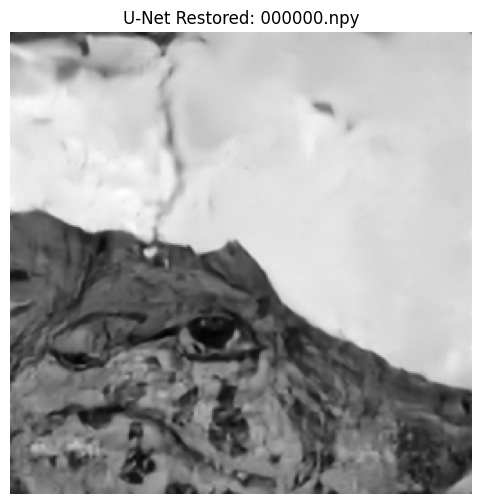

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import os

filename = files[0]

restored = np.load(
    os.path.join(OUTPUT_DIR, filename)
)

print("Filename:", filename)
print("Shape:", restored.shape)
print("Min:", restored.min())
print("Max:", restored.max())

plt.figure(figsize=(6, 6))
plt.imshow(restored, cmap="gray")
plt.title(f"U-Net Restored: {filename}")
plt.axis("off")
plt.show()

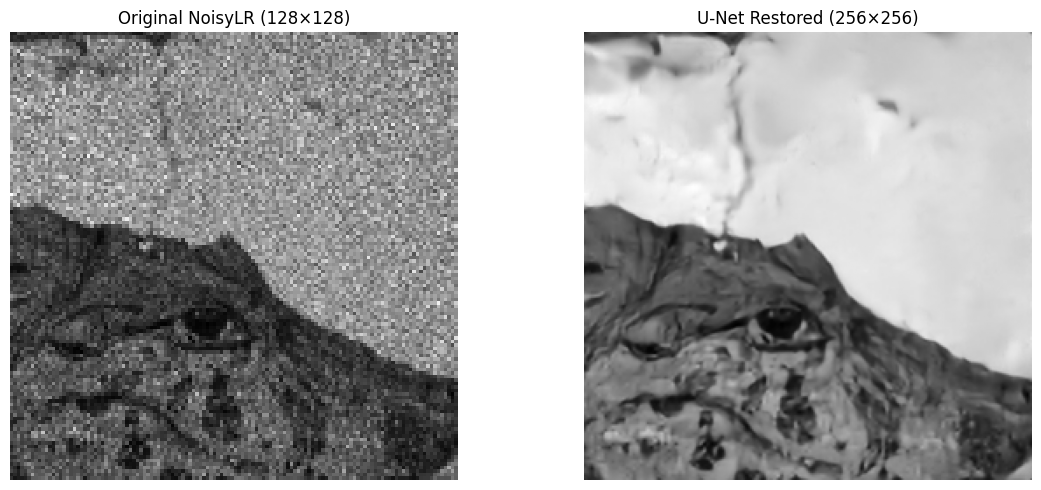

In [28]:
filename = files[0]

# Original 128x128 noisy image
noisy = np.load(
    os.path.join(TEST_DIR, filename)
).astype(np.float32)

# Restored 256x256 image
restored = np.load(
    os.path.join(OUTPUT_DIR, filename)
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(noisy, cmap="gray")
plt.title("Original NoisyLR (128×128)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(restored, cmap="gray")
plt.title("U-Net Restored (256×256)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
import shutil

zip_path = shutil.make_archive(
    "/kaggle/working/restored_test",
    "zip",
    OUTPUT_DIR
)

print("ZIP created:")
print(zip_path)

ZIP created:
/kaggle/working/restored_test.zip


In [30]:
import os
import time
import numpy as np
import torch
import torch.nn.functional as F
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# --------------------------------------------------
# Paths
# --------------------------------------------------

GT_DIR = "/kaggle/input/datasets/abishah/semicon/train/train/GT"
NOISY_DIR = "/kaggle/input/datasets/abishah/semicon/train/train/NoisyLR"

# --------------------------------------------------
# Model
# --------------------------------------------------

model.eval()

psnr_scores = []
ssim_scores = []
inference_times = []

print("Starting validation evaluation...")
print("Validation images:", len(val_files))
print("----------------------------------------")

# --------------------------------------------------
# Evaluate every validation image
# --------------------------------------------------

for i, filename in enumerate(val_files):

    # Load NoisyLR and Ground Truth
    noisy = np.load(
        os.path.join(NOISY_DIR, filename)
    ).astype(np.float32)

    gt = np.load(
        os.path.join(GT_DIR, filename)
    ).astype(np.float32)

    # Convert NoisyLR to tensor
    x = torch.from_numpy(noisy).unsqueeze(0).unsqueeze(0)
    x = x.to(device)

    # 128x128 -> 256x256
    x = F.interpolate(
        x,
        size=(256, 256),
        mode="bicubic",
        align_corners=False
    )

    # Measure inference time
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.time()

    with torch.no_grad():
        output = model(x)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end_time = time.time()

    inference_times.append(
        (end_time - start_time) * 1000
    )

    # Convert output to numpy
    restored = output[0, 0].cpu().numpy()

    # Keep output in valid image range
    restored = np.clip(restored, 0.0, 1.0)

    # Calculate PSNR
    psnr = peak_signal_noise_ratio(
        gt,
        restored,
        data_range=1.0
    )

    # Calculate SSIM
    ssim = structural_similarity(
        gt,
        restored,
        data_range=1.0
    )

    psnr_scores.append(psnr)
    ssim_scores.append(ssim)

    if (i + 1) % 50 == 0:
        print(f"Evaluated {i+1}/{len(val_files)} images")

# --------------------------------------------------
# Final results
# --------------------------------------------------

mean_psnr = np.mean(psnr_scores)
mean_ssim = np.mean(ssim_scores)
mean_inference = np.mean(inference_times)

print("\n========================================")
print("       U-NET VALIDATION RESULTS")
print("========================================")

print(f"Images evaluated       : {len(val_files)}")
print(f"Mean PSNR              : {mean_psnr:.4f} dB")
print(f"Mean SSIM              : {mean_ssim:.6f}")
print(f"Average inference time : {mean_inference:.2f} ms/image")
print(f"Total inference time   : {sum(inference_times)/1000:.2f} seconds")

print("========================================")

Starting validation evaluation...
Validation images: 320
----------------------------------------
Evaluated 50/320 images
Evaluated 100/320 images
Evaluated 150/320 images
Evaluated 200/320 images
Evaluated 250/320 images
Evaluated 300/320 images

       U-NET VALIDATION RESULTS
Images evaluated       : 320
Mean PSNR              : 28.0510 dB
Mean SSIM              : 0.760545
Average inference time : 24.02 ms/image
Total inference time   : 7.69 seconds


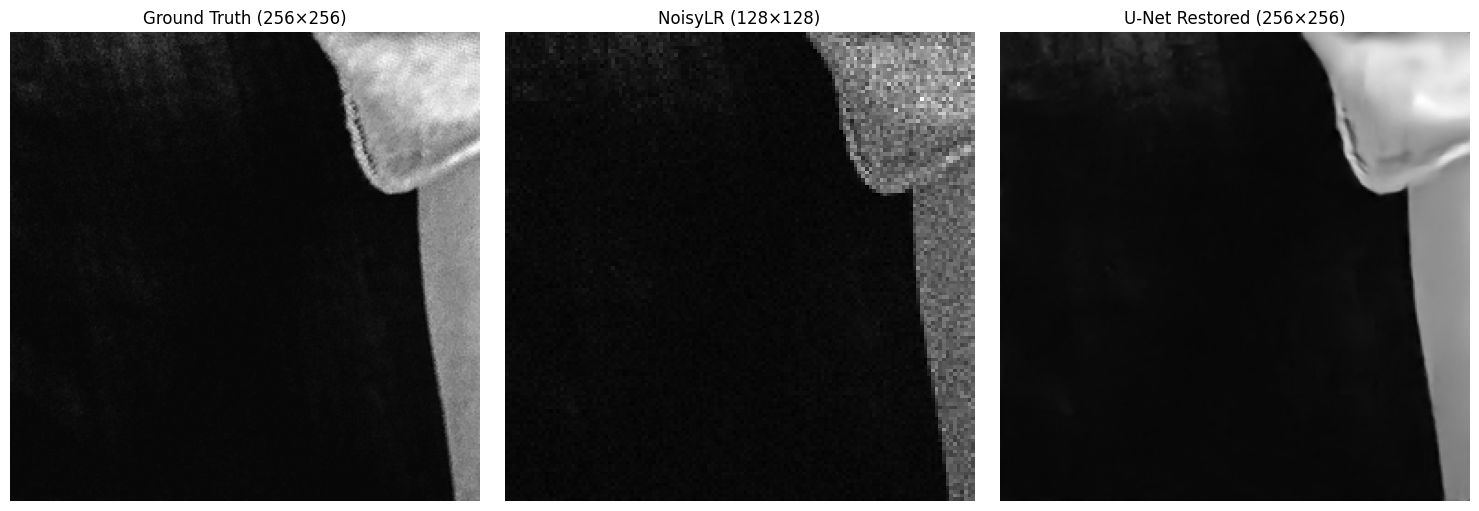

In [31]:
# Select one validation image
filename = val_files[0]

# Load images
noisy = np.load(
    os.path.join(NOISY_DIR, filename)
).astype(np.float32)

gt = np.load(
    os.path.join(GT_DIR, filename)
).astype(np.float32
)

# Prepare input
x = torch.from_numpy(noisy).unsqueeze(0).unsqueeze(0).to(device)

x = F.interpolate(
    x,
    size=(256, 256),
    mode="bicubic",
    align_corners=False
)

# Restore
with torch.no_grad():
    output = model(x)

restored = output[0, 0].cpu().numpy()
restored = np.clip(restored, 0, 1)

# Display
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gt, cmap="gray")
plt.title("Ground Truth (256×256)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(noisy, cmap="gray")
plt.title("NoisyLR (128×128)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(restored, cmap="gray")
plt.title("U-Net Restored (256×256)")
plt.axis("off")

plt.tight_layout()
plt.show()

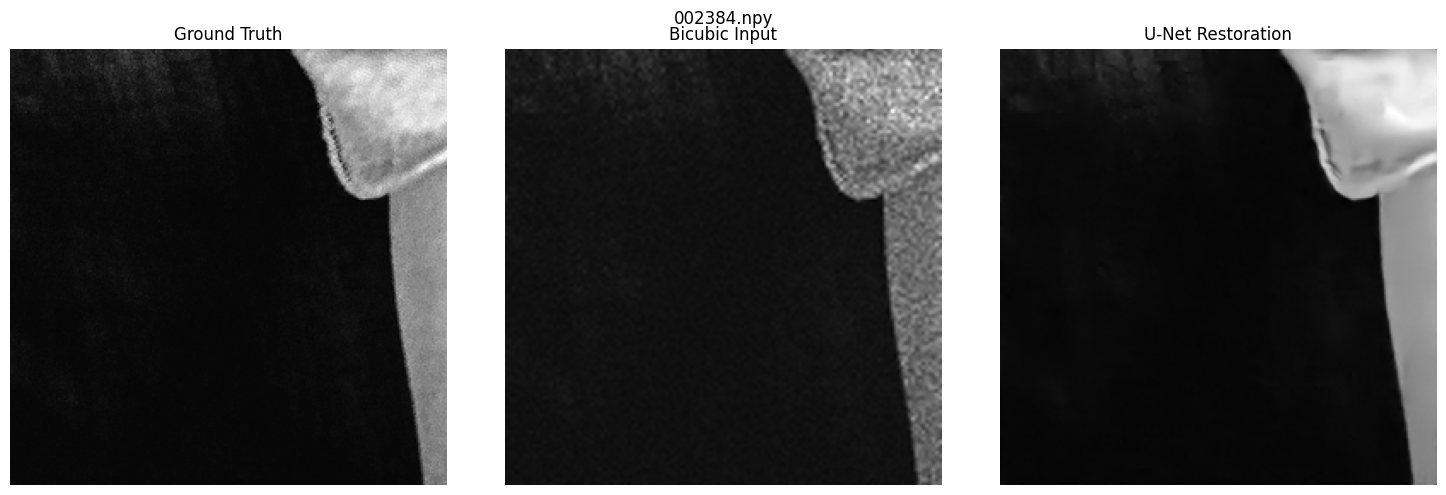

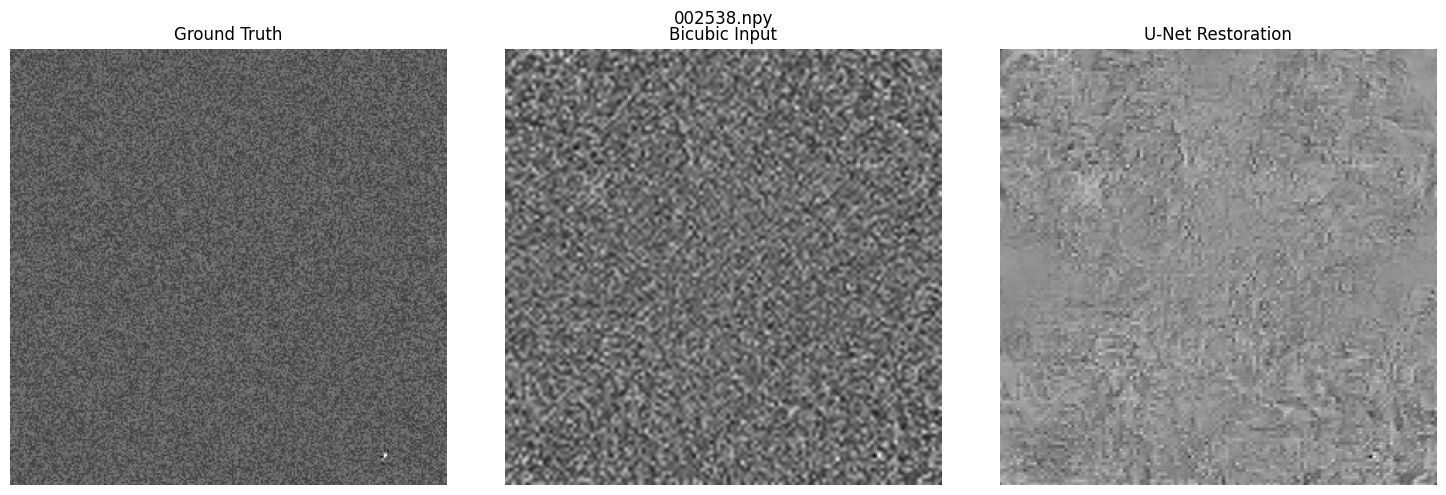

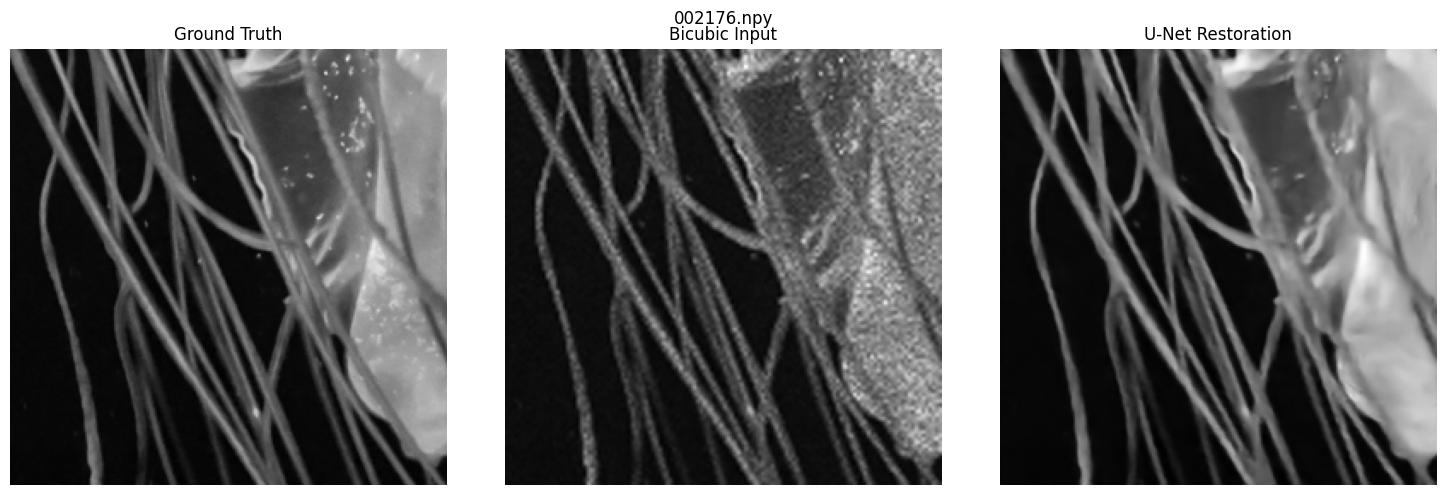

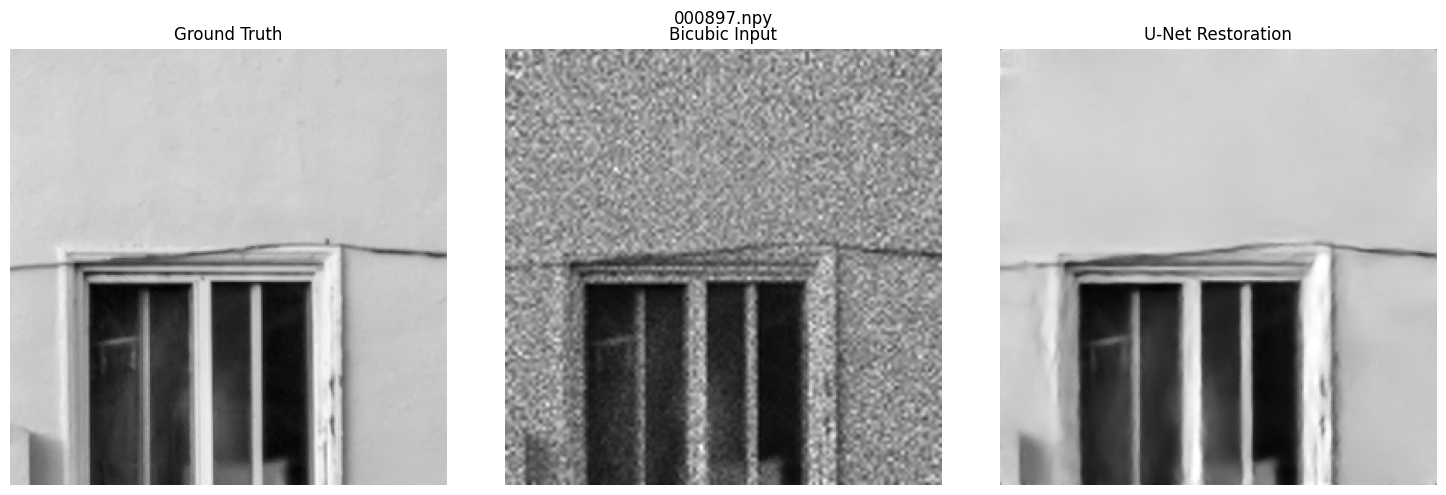

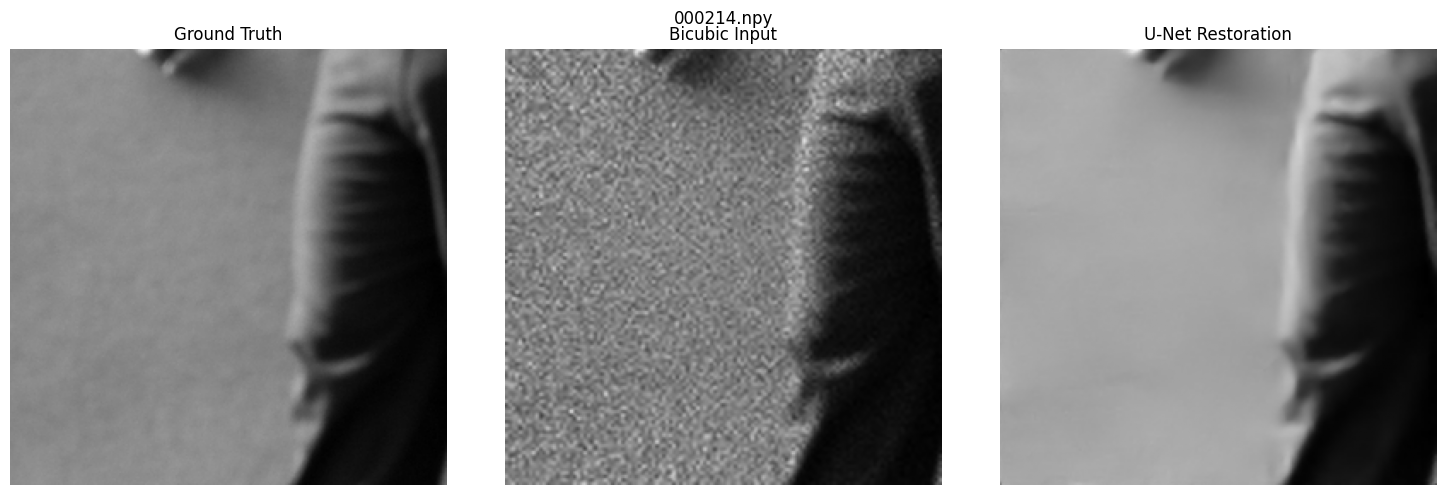

In [34]:
# Visual comparison for 5 validation images

import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import torch.nn.functional as F

model.eval()

# Select 5 validation images
sample_files = val_files[:5]

for filename in sample_files:

    noisy = np.load(
        os.path.join(NOISY_DIR, filename)
    ).astype(np.float32)

    gt = np.load(
        os.path.join(GT_DIR, filename)
    ).astype(np.float32)

    # Prepare input
    x = torch.from_numpy(noisy).unsqueeze(0).unsqueeze(0).to(device)

    x = F.interpolate(
        x,
        size=(256, 256),
        mode="bicubic",
        align_corners=False
    )

    # Restore
    with torch.no_grad():
        output = model(x)

    restored = output[0, 0].cpu().numpy()
    restored = np.clip(restored, 0, 1)

    # Display
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(gt, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(x[0, 0].cpu().numpy(), cmap="gray")
    plt.title("Bicubic Input")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(restored, cmap="gray")
    plt.title("U-Net Restoration")
    plt.axis("off")

    plt.suptitle(filename)
    plt.tight_layout()
    plt.show()

In [32]:
UNET_PSNR = 28.0438
UNET_SSIM = 0.757247
UNET_INFERENCE_MS = 25.82
UNET_PARAMS = 16325313

print("U-Net baseline saved:")
print(f"PSNR       : {UNET_PSNR:.4f} dB")
print(f"SSIM       : {UNET_SSIM:.6f}")
print(f"Inference  : {UNET_INFERENCE_MS:.2f} ms/image")
print(f"Parameters : {UNET_PARAMS:,}")

U-Net baseline saved:
PSNR       : 28.0438 dB
SSIM       : 0.757247
Inference  : 25.82 ms/image
Parameters : 16,325,313
